## Experiment Workflow Test
Short notebook to validate the new experiment file workflow (`experiments/podmr.py` and `experiments/rabi.py`).

In [23]:
# Adjust if your VS Code kernel needs help finding pip / scripts
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [24]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from scipy.optimize import curve_fit
import qickdawg as qd
from importlib.metadata import version

print(f"numpy     {version('numpy')}")
print(f"qickdawg  {version('qickdawg')}")
print(f"python    {sys.version}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
numpy     2.3.3
qickdawg  1.2.1
python    3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


<a id="connect"></a>
### Connect to board

In [25]:
qd.start_client('192.168.3.1')
print("Connected — soccfg loaded:", qd.soccfg is not None)

Connected — soccfg loaded: True


In [26]:
default_config = qd.NVConfiguration()

default_config.adc_channel              = 0
default_config.mw_channel               = 0
default_config.mw_nqz                   = 1
default_config.mw_gain                  = 1800
default_config.laser_gate_pmod          = 0
default_config.laser_on_tus             = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns  = 300
default_config.mw_laser_delay_treg      = 0
default_config.relax_delay_tus          = 1.1
default_config.pre_init                 = True
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

In [27]:
config = copy(default_config)
config.one_ftns = 52.06/2
config.one_ftsamp

128

<a id="top"></a>
# Table of Contents
1. [Connect to board](#connect)
2. [Laser](#laser)
3. [Counting Duration](#cd)
3. [PODMR](#podmr)
4. [RABI](#rabi)
5. [Ramsey](#ramsey)
6. [Hahn Echo](#hahn-echo)
7. [CPMG](#cpmg)
8. [CPMG Reopt Loop](#cpmg-reopt)

<a id="laser"></a>
### Laser
[Back to top](#top)

In [29]:
# Expected: laser should illuminate the sample
qd.laser_on(copy(default_config))

0

In [30]:
# Expected: laser should turn off
qd.laser_off(copy(default_config))

0

### PL counts — live scope

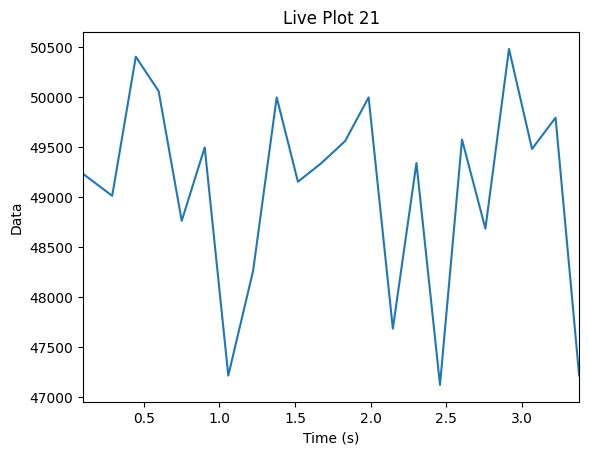

In [7]:
config = copy(default_config)
config.readout_integration_treg = 2**16 - 1
config.reps = 300
config.relax_delay_tns = 0

prog = qd.PLIntensity(config)

def get_cps():
    d = prog.acquire(progress=False)
    return d / (config.readout_integration_tus * 1e-6 * config.reps)

qd.live_plot(get_cps)

<a id="cd"></a>
### Counting Duration

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.


Counting-duration sweep:   0%|          | 0/150 [00:00<?, ?step/s]

Saved figure: c:\Users\QT3 User Facility\Documents\qick-dawg\data\counting_duration\counting_duration_full_res_20260331_162739_raw_and_subtracted.png
Saved figure: c:\Users\QT3 User Facility\Documents\qick-dawg\data\counting_duration\counting_duration_full_res_20260331_162739_snr.png


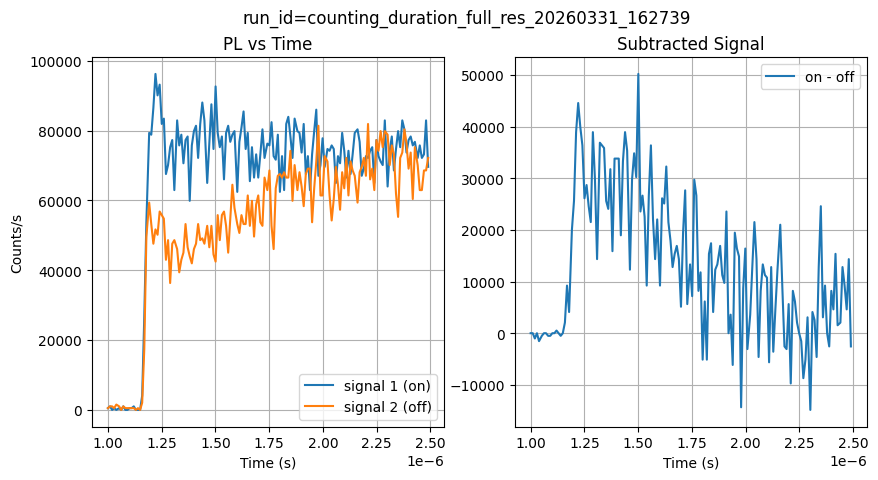

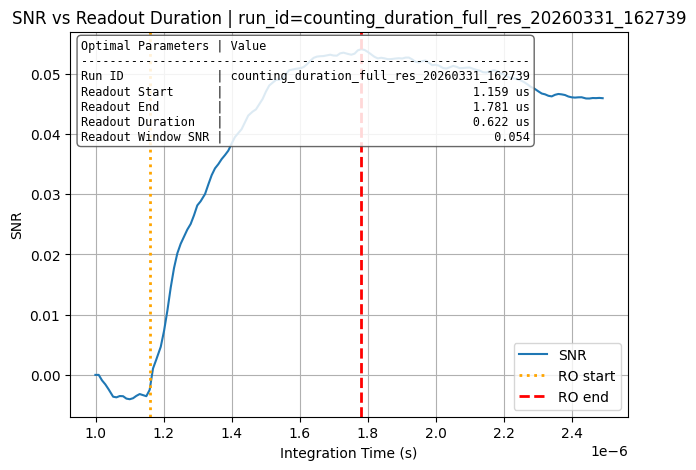

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/counting_duration.py

<a id="podmr"></a>
### PODMR
Edit parameters in `experiments/podmr.py` (EXPERIMENT PARAMETERS block), then run this cell.
The script handles connection, sweep config, acquisition, HDF5 save, and plot internally.
Use `%run -i` to inject variable overrides from a prior cell without editing the file.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.065 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 1844.5 to 1847.5 by 0.05
Instead using 1844.4999996185302 to 1847.5000225067138 by 0.05000038146972656 in 61 steps
[podmr] Sweep: 1844.500 -> 1847.500 MHz (delta 0.050 MHz)
[podmr] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=1200
[podmr] pi pulse: override_mw_pi_ftns=949.9104817708334


  0%|          | 0/12200000 [00:00<?, ?it/s]

[podmr] Saved -> c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_fine_res_20260504_001929.h5


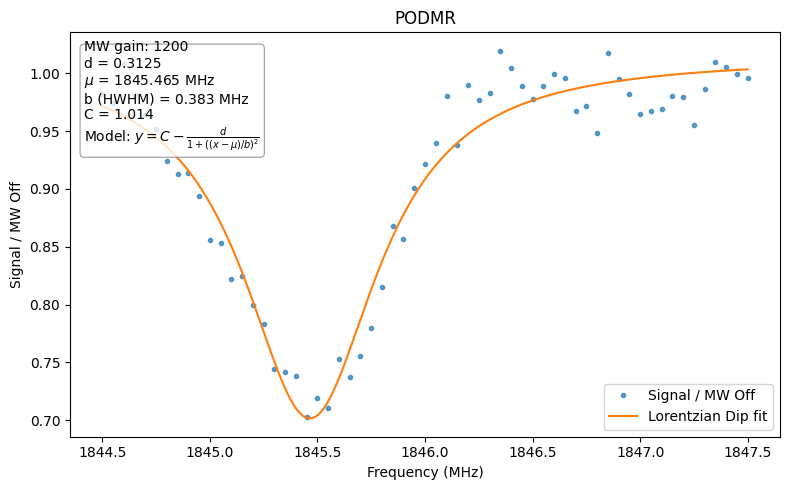

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/podmr.py

<a id="rabi"></a>
### RABI
Edit parameters in `experiments/rabi.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/rabi.py

[config] Documented Excitation Power is 0.065 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 5 to 400 by 0.2
Instead using 5.086263020833334 to 406.9010416666667 by 0.20345052083333334 in 1976 steps
[rabi] Sweep: 5.000 -> 400.000 ns (delta 0.200 ns)
[rabi] Active transition: lower_dip | freq=1845.8000003814695 MHz | gain=32767

Requested 5 to 400 by 0.2
Instead using 5.086263020833334 to 406.9010416666667 by 0.20345052083333334 in 1976 steps


  0%|          | 0/79040000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.



Requested 5 to 400 by 0.2
Instead using 5.086263020833334 to 406.9010416666667 by 0.20345052083333334 in 1976 steps


  0%|          | 0/79040000 [00:00<?, ?it/s]

...

  0%|          | 0/79040000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.



Requested 5 to 400 by 0.2
Instead using 5.086263020833334 to 406.9010416666667 by 0.20345052083333334 in 1976 steps


  0%|          | 0/39520000 [00:00<?, ?it/s]

[combine] wrote c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_fine_res_run_20260504_003922\rabi_fine_res_combined.h5
[rabi_fine_res] Chunked run complete: {'run_id': '20260504_003922', 'run_dir': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\rabi\\rabi_fine_res_run_20260504_003922', 'manifest_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\rabi\\rabi_fine_res_run_20260504_003922\\run_manifest.jsonl', 'summary_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\rabi\\rabi_fine_res_run_20260504_003922\\run_summary.csv', 'combined_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\rabi\\rabi_fine_res_run_20260504_003922\\rabi_fine_res_combined.h5'}


Using file: ..\data\rabi\rabi_fine_res_20260504_003922.h5


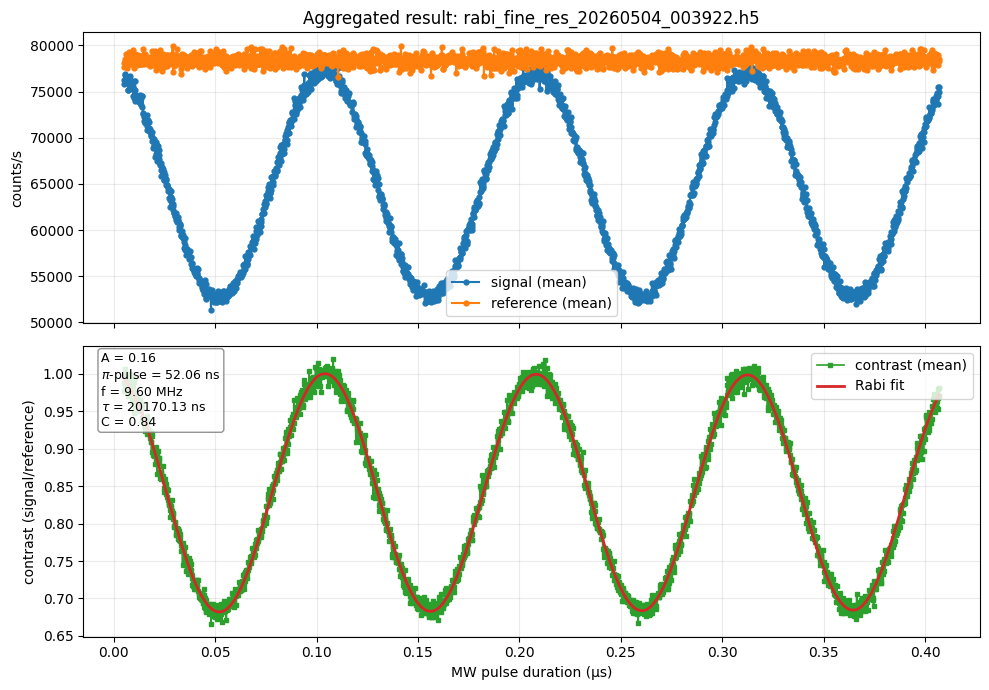

Plotted 1976 points from aggregated data


In [20]:
# Plot aggregated data from the unified HDF5 file.
# The file contains /aggregated/data/ with pre-computed weighted averages
# and /chunks/chunk_NNN/ with per-chunk raw data if needed.
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import OptimizeWarning
import warnings
import re

DATA_ROOT = Path("..") / "data" / "rabi"
# Search for unified HDF5 files in direct directory (not old format subdirectories)
# Unified format: {experiment_name}_{YYYYMMDD_HHMMSS}.h5
h5_direct = sorted([f for f in DATA_ROOT.glob('*.h5') if f.is_file()], reverse=True)
unified_pattern = re.compile(r'^[a-z_]+_\d{8}_\d{6}\.h5$', re.IGNORECASE)
h5_candidates = [f for f in h5_direct if unified_pattern.match(f.name)]

if not h5_candidates:
    # Fallback: search subdirectories for converted files
    h5_all = sorted(DATA_ROOT.rglob('*.h5'), reverse=True)
    h5_candidates = [f for f in h5_all if unified_pattern.match(f.name)]

if not h5_candidates:
    raise FileNotFoundError(f'No unified .h5 files found in {DATA_ROOT.resolve()}. Expected format: {{name}}_YYYYMMDD_HHMMSS.h5')
output_path = h5_candidates[0]
print(f'Using file: {output_path}')

# Load aggregated data from the unified file
with h5py.File(output_path, 'r') as hf:
    # Check if this is the new unified format
    if 'aggregated' in hf and 'data' in hf['aggregated']:
        # New unified format: read aggregated averages
        agg_data = hf['aggregated/data']
        x_ns = None
        sig = None
        ref = None

        # Find the axis dataset
        for axis_name in ['mw_duration_ftns', 'tau_ftns', 'tau_ns', 'sweep_pts', 'mw_duration_ns']:
            if axis_name in agg_data:
                x_ns = np.asarray(agg_data[axis_name], dtype=float)
                break

        # Find signal/reference/contrast
        for sig_name in ['signal1_cts_s', 'signal1']:
            if sig_name in agg_data:
                sig = np.asarray(agg_data[sig_name], dtype=float)
                break

        for ref_name in ['reference1_cts_s', 'reference1', 'signal2_cts_s', 'signal2']:
            if ref_name in agg_data:
                ref = np.asarray(agg_data[ref_name], dtype=float)
                break

        contrast = None
        if 'contrast' in agg_data:
            contrast = np.asarray(agg_data['contrast'], dtype=float)
        elif sig is not None and ref is not None:
            contrast = sig / np.clip(ref, 1e-12, None)
    else:
        # Fallback for old format (if needed)
        raise ValueError('File does not contain /aggregated/data. Ensure it was created with the new unified format.')

if sig is None or ref is None:
    raise KeyError('Could not locate signal/reference in aggregated data.')
if x_ns is None:
    x_ns = np.arange(sig.size, dtype=float)

# Ensure arrays are 1D and aligned
minlen = min(len(x_ns), len(sig), len(ref))
x_ns = x_ns[:minlen]
sig = sig[:minlen]
ref = ref[:minlen]
if contrast is not None:
    contrast = contrast[:minlen]
else:
    contrast = sig / np.clip(ref, 1e-12, None)

x_us = x_ns / 1e3

# Rabi fit model similar to Visualizer.plot_rabi()
def decaying_cos(x, A, T, C, tau):
    return A * np.cos(x * 2 * np.pi / T) * np.exp(-x / tau) + C


def rabi_initial_guess(x, y):
    span = max(float(np.max(x) - np.min(x)), 1e-12)
    y = np.asarray(y, dtype=float)
    y_mean = float(np.mean(y))
    y_centered = y - y_mean
    dx = max(float(np.median(np.diff(x))) if len(x) > 1 else span, 1e-12)
    freqs = np.fft.rfftfreq(len(y_centered), d=dx)
    spectrum = np.abs(np.fft.rfft(y_centered))
    if len(freqs) > 1 and len(spectrum) > 1:
        best_idx = 1 + int(np.argmax(spectrum[1:]))
        best_idx = min(best_idx, len(freqs) - 1)
        f0 = float(freqs[best_idx])
        T0 = 1.0 / max(f0, 1e-12)
    else:
        T0 = span
    A0 = 0.5 * (float(np.max(y)) - float(np.min(y)))
    tau0 = 100.0
    return [A0, T0, y_mean, tau0]


def format_rabi_params(p):
    A, T, C, tau = p
    freq = 1.0 / T if T != 0 else 0.0
    return [
        f'A = {A:.2f}',
        rf'$\pi$-pulse = {T/2:.2f} ns',
        f'f = {freq*1e3:.2f} MHz',
        rf'$\tau$ = {tau:.2f} ns',
        f'C = {C:.2f}',
    ]


fit_params = None
fit_x = None
fit_y = None
fit_summary_lines = None
fit_target = contrast

try:
    p0 = rabi_initial_guess(x_ns, fit_target)
    bounds = (
        [0.0, 1e-9, float(np.min(fit_target)) - abs(float(np.ptp(fit_target))) * 2.0 - 1e-9, 1e-9],
        [abs(float(np.ptp(fit_target))) * 10.0 + 1e-9, max(float(np.ptp(x_ns)) * 10.0, 1e-9), float(np.max(fit_target)) + abs(float(np.ptp(fit_target))) * 2.0 + 1e-9, max(float(np.ptp(x_ns)) * 200.0, 1e-9)],
    )
    with warnings.catch_warnings():
        warnings.simplefilter('error', OptimizeWarning)
        fit_params, _ = curve_fit(
            decaying_cos,
            x_ns,
            fit_target,
            p0=p0,
            bounds=bounds,
            maxfev=20000,
        )
    fit_x = np.linspace(float(np.min(x_ns)), float(np.max(x_ns)), 1000)
    fit_y = decaying_cos(fit_x, *fit_params)
    fit_summary_lines = format_rabi_params(fit_params)
except Exception as exc:
    print(f'Rabi fit failed: {exc}')

# Plot aggregated averages
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax1.plot(x_us, sig, 'o-', lw=1.5, ms=3.5, label='signal (mean)', color='tab:blue')
ax1.plot(x_us, ref, 'o-', lw=1.5, ms=3.5, label='reference (mean)', color='tab:orange')
ax1.set_ylabel('counts/s')
ax1.set_title(f'Aggregated result: {output_path.name}')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(x_us, contrast, 's-', lw=1.2, ms=3.2, color='tab:green', label='contrast (mean)')
if fit_x is not None and fit_y is not None:
    ax2.plot(fit_x / 1e3, fit_y, '-', lw=2.0, color='tab:red', label='Rabi fit')
ax2.set_xlabel('MW pulse duration (µs)')
ax2.set_ylabel('contrast (signal/reference)')
ax2.grid(alpha=0.25)
ax2.legend()

if fit_summary_lines:
    ax2.text(
        0.02,
        0.98,
        '\n'.join(fit_summary_lines),
        transform=ax2.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='gray'),
    )

plt.tight_layout()
plt.show()
print(f'Plotted {minlen} points from aggregated data')

In [18]:
# Convert old chunked format to new unified HDF5 format
# Reads: individual chunk_*.h5 files + optional combined.h5
# Writes: {experiment_name}_{run_id}.h5 with /metadata/, /aggregated/, /chunks/ structure

from pathlib import Path
import h5py
import numpy as np
import json
from datetime import UTC, datetime

DATA_ROOT = Path("..") / "data" / "rabi"
run_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir() and "_run_" in d.name], reverse=True)

if not run_dirs:
    raise FileNotFoundError(f"No run directories found in {DATA_ROOT}")

old_run_dir = run_dirs[0]
print(f"Converting old format run: {old_run_dir}")

# Find all chunk files
chunk_files = sorted(old_run_dir.glob("*_chunk_*.h5"))
if not chunk_files:
    raise FileNotFoundError(f"No chunk files found in {old_run_dir}")

print(f"Found {len(chunk_files)} chunk files")

# Extract run_id from directory name (e.g., "rabi_fine_res_run_20260504_003922")
dir_stem = old_run_dir.name
run_id = dir_stem.split("_run_")[-1]  # "20260504_003922"
experiment_name = dir_stem.split("_run_")[0]  # "rabi_fine_res"

print(f"run_id: {run_id}, experiment_name: {experiment_name}")

# Read first chunk to understand structure
with h5py.File(chunk_files[0], 'r') as hf:
    # Collect all datasets from first chunk
    first_chunk_data = {}
    if 'data' in hf:
        for key in hf['data'].keys():
            first_chunk_data[key] = np.asarray(hf['data'][key], dtype=float)
    
    # Get metadata attributes
    first_chunk_attrs = {}
    if 'experiment' in hf:
        for k, v in hf['experiment'].attrs.items():
            first_chunk_attrs[k] = v
    if 'resolved_config' in hf:
        for k, v in hf['resolved_config'].attrs.items():
            first_chunk_attrs[k] = v

print(f"First chunk datasets: {list(first_chunk_data.keys())}")

# Create new unified output file
output_h5_path = DATA_ROOT / f"{experiment_name}_{run_id}.h5"
print(f"Writing new unified file: {output_h5_path}")

with h5py.File(output_h5_path, 'w') as hf_out:
    # Create metadata group with run-level info
    meta_grp = hf_out.create_group('metadata')
    meta_grp.attrs['run_id'] = str(run_id)
    meta_grp.attrs['experiment_name'] = str(experiment_name)
    meta_grp.attrs['timestamp_conversion'] = datetime.now(UTC).isoformat(timespec='seconds')
    meta_grp.attrs['converted_from_old_format'] = True
    
    # Initialize aggregated data structures
    agg_grp = hf_out.create_group('aggregated')
    agg_data_grp = agg_grp.create_group('data')
    
    # Find axis and data arrays
    axis_name = None
    for candidate in ['mw_duration_ftns', 'tau_ftns', 'tau_ns', 'sweep_pts', 'mw_duration_ns']:
        if candidate in first_chunk_data:
            axis_name = candidate
            break
    
    if axis_name:
        x_axis = first_chunk_data[axis_name]
        agg_data_grp.create_dataset(axis_name, data=x_axis)
    
    # Initialize accumulators for weighted averaging
    weighted_data = {}
    total_weight = 0.0
    
    # Process each chunk
    chunks_grp = hf_out.create_group('chunks')
    
    for chunk_idx, chunk_file in enumerate(chunk_files):
        with h5py.File(chunk_file, 'r') as hf_chunk:
            chunk_data = {}
            if 'data' in hf_chunk:
                for key in hf_chunk['data'].keys():
                    chunk_data[key] = np.asarray(hf_chunk['data'][key], dtype=float)
            
            chunk_attrs = {}
            if 'experiment' in hf_chunk:
                for k, v in hf_chunk['experiment'].attrs.items():
                    chunk_attrs[k] = v
            
            # Extract chunk reps from attributes or filename
            chunk_reps = int(chunk_attrs.get('loop_chunk_reps', 1))
            
            # Create chunk group in output
            chunk_grp = chunks_grp.create_group(f'chunk_{chunk_idx:04d}')
            meta_chunk_grp = chunk_grp.create_group('metadata')
            data_chunk_grp = chunk_grp.create_group('data')
            
            # Store chunk metadata
            meta_chunk_grp.attrs['chunk_index'] = chunk_idx
            meta_chunk_grp.attrs['chunk_reps'] = chunk_reps
            meta_chunk_grp.attrs['chunk_file_source'] = str(chunk_file.name)
            
            # Store chunk data
            for key, arr in chunk_data.items():
                # Skip axis datasets
                if key in (axis_name, 'mw_duration_ftns', 'tau_ftns', 'tau_ns', 'sweep_pts', 'mw_duration_ns'):
                    continue
                data_chunk_grp.create_dataset(key, data=arr)
            
            # Accumulate for aggregated data
            for key, arr in chunk_data.items():
                if key in (axis_name, 'mw_duration_ftns', 'tau_ftns', 'tau_ns', 'sweep_pts', 'mw_duration_ns'):
                    continue
                if key not in weighted_data:
                    weighted_data[key] = np.zeros_like(arr, dtype=float)
                weighted_data[key] += chunk_reps * arr
            
            total_weight += chunk_reps
        
        print(f"  Processed chunk {chunk_idx}: {chunk_file.name}")
    
    # Finalize aggregated data
    agg_grp.attrs['total_weight'] = float(total_weight)
    for key, weighted_arr in weighted_data.items():
        avg_arr = weighted_arr / total_weight if total_weight > 0 else weighted_arr
        agg_data_grp.create_dataset(key, data=avg_arr)
    
    meta_grp.attrs['n_chunks'] = len(chunk_files)
    meta_grp.attrs['total_reps'] = int(total_weight)
    meta_grp.attrs['timestamp_end'] = datetime.now(UTC).isoformat(timespec='seconds')

print(f"\n✓ Conversion complete!")
print(f"  New file: {output_h5_path}")
print(f"  Size: {output_h5_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"  Contains {len(chunk_files)} chunks with total {int(total_weight)} reps")

# Verify the new file
with h5py.File(output_h5_path, 'r') as hf:
    print(f"\nNew file structure:")
    print(f"  /metadata/ with {len(hf['metadata'].attrs)} attributes")
    print(f"  /aggregated/data/ with {len(hf['aggregated/data'])} datasets")
    print(f"  /chunks/ with {len(hf['chunks'])} chunk groups")

Converting old format run: ..\data\rabi\rabi_fine_res_run_20260504_003922
Found 13 chunk files
run_id: 20260504_003922, experiment_name: rabi_fine_res
First chunk datasets: ['contrast', 'mw_duration_ftns', 'mw_duration_ftsamp', 'mw_duration_ftus', 'reference1', 'reference1_cts_s', 'reference2', 'reference2_cts_s', 'signal1', 'signal1_cts_s', 'signal2', 'signal2_cts_s', 'sweep_pts']
Writing new unified file: ..\data\rabi\rabi_fine_res_20260504_003922.h5
  Processed chunk 0: rabi_fine_res_chunk_20260504_010228.h5
  Processed chunk 1: rabi_fine_res_chunk_20260504_012554.h5
  Processed chunk 2: rabi_fine_res_chunk_20260504_014918.h5
  Processed chunk 3: rabi_fine_res_chunk_20260504_021242.h5
  Processed chunk 4: rabi_fine_res_chunk_20260504_023606.h5
  Processed chunk 5: rabi_fine_res_chunk_20260504_025930.h5
  Processed chunk 6: rabi_fine_res_chunk_20260504_032254.h5
  Processed chunk 7: rabi_fine_res_chunk_20260504_034618.h5
  Processed chunk 8: rabi_fine_res_chunk_20260504_040942.h5
  P

<a id="ramsey"></a>
### Ramsey
Edit parameters in `experiments/ramsey.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [34]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/ramsey.py

[config] Documented Excitation Power is 0.065 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 200.0 to 15000.0 by 100.0
Instead using 199.99186197916669 to 15014.444986979168 by 100.09765625 in 149 steps
[ramsey] Sweep: 199.992 -> 15014.445 ftns (linear, configured delta=100.098)
[ramsey] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=32767
[ramsey] mw_pi2_ftsamp=128, reps=80000

Requested 200.0 to 15000.0 by 100.0
Instead using 199.99186197916669 to 15014.444986979168 by 100.09765625 in 149 steps


  0%|          | 0/11920000 [00:00<?, ?it/s]

KeyboardInterrupt: 

Using file: ..\data\ramsey\ramsey_fine_res_20260504_120913.h5


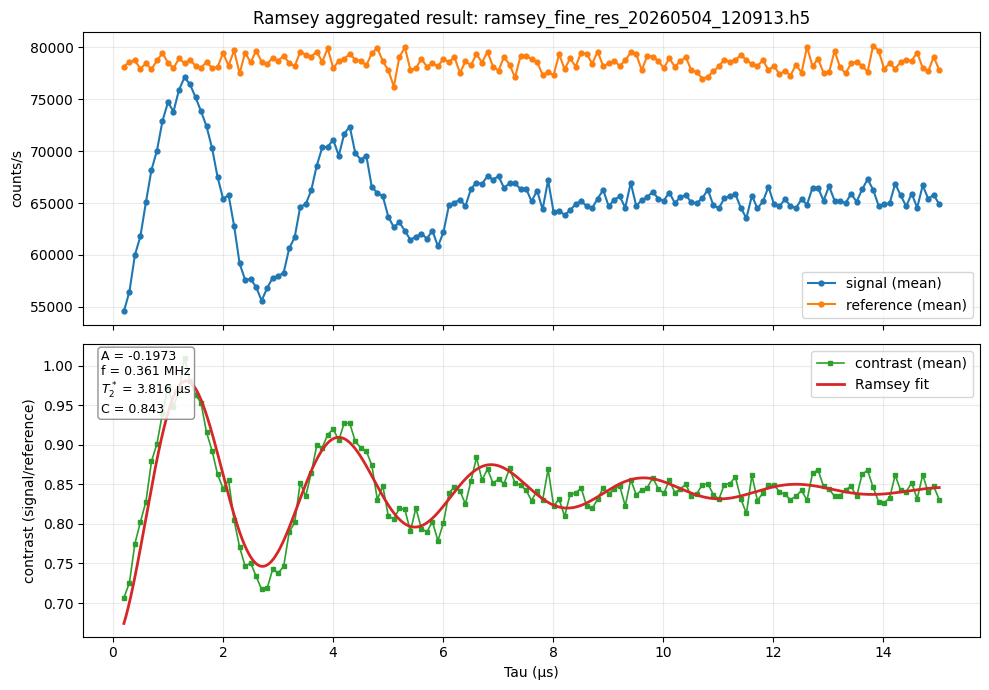

Plotted 1976 points from aggregated Ramsey data


In [43]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, OptimizeWarning
import warnings
import re


def _load_latest_ramsey_file(data_root):
    data_root = Path(data_root)
    unified_pattern = re.compile(r'^ramsey_fine_res_\d{8}_\d{6}\.h5$', re.IGNORECASE)
    candidates = sorted([f for f in data_root.glob('ramsey_fine_res_*.h5') if f.is_file()], reverse=True)
    candidates = [f for f in candidates if unified_pattern.match(f.name)]
    if not candidates:
        raise FileNotFoundError(f'No unified Ramsey .h5 files found in {data_root.resolve()}')

    for path in candidates:
        with h5py.File(path, 'r') as hf:
            if 'aggregated' in hf and 'data' in hf['aggregated']:
                return path

    raise ValueError(f'No Ramsey file in {data_root.resolve()} contains /aggregated/data')


def _load_aggregated_arrays(h5_path):
    with h5py.File(h5_path, 'r') as hf:
        if 'aggregated' not in hf or 'data' not in hf['aggregated']:
            raise ValueError(f'{h5_path.name} does not contain /aggregated/data')
        data_grp = hf['aggregated/data']

        x_ns = None
        for axis_name in ['tau_ftns', 'tau_ns', 'tau_tus', 'sweep_pts']:
            if axis_name in data_grp:
                x_ns = np.asarray(data_grp[axis_name], dtype=float).reshape(-1)
                break

        signal = None
        for sig_name in ['signal1_cts_s', 'signal1']:
            if sig_name in data_grp:
                signal = np.asarray(data_grp[sig_name], dtype=float).reshape(-1)
                break

        reference = None
        for ref_name in ['reference1_cts_s', 'reference1', 'signal2_cts_s', 'signal2']:
            if ref_name in data_grp:
                reference = np.asarray(data_grp[ref_name], dtype=float).reshape(-1)
                break

        contrast = None
        if 'contrast' in data_grp:
            contrast = np.asarray(data_grp['contrast'], dtype=float).reshape(-1)
        elif signal is not None and reference is not None:
            contrast = signal / np.clip(reference, 1e-12, None)

    if signal is None or reference is None:
        raise KeyError('Could not locate signal/reference in aggregated Ramsey data.')
    if x_ns is None:
        x_ns = np.arange(signal.size, dtype=float)
    if contrast is None:
        contrast = signal / np.clip(reference, 1e-12, None)

    minlen = min(len(x_ns), len(signal), len(reference), len(contrast))
    return x_ns[:minlen], signal[:minlen], reference[:minlen], contrast[:minlen]


# Ramsey fit model similar to Visualizer.plot_ramsey(..., fit_mode="oscillatory")
def ramsey_model(x, A, f, t2star, C):
    return A * np.exp(-x / t2star) * np.cos(2 * np.pi * f * x) + C


def _fft_frequency_guesses(x, y, max_guesses=5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    dx = max(float(np.median(np.diff(x))) if len(x) > 1 else 1.0, 1e-12)
    centered = y - float(np.mean(y))
    spectrum = np.abs(np.fft.rfft(centered))
    freqs = np.fft.rfftfreq(len(centered), d=dx)

    if len(freqs) <= 1 or len(spectrum) <= 1:
        return [1.0 / max(float(np.ptp(x)), 1e-12)]

    ranked = np.argsort(spectrum[1:])[::-1] + 1
    guesses = []
    for idx in ranked[:max_guesses]:
        freq = float(freqs[idx])
        if freq > 0:
            guesses.append(freq)

    if not guesses:
        guesses.append(1.0 / max(float(np.ptp(x)), 1e-12))

    return guesses


def ramsey_initial_guess(x, y, f0):
    span = max(float(np.ptp(x)), 1e-9)
    return [0.5 * (float(np.max(y)) - float(np.min(y))), max(f0, 1e-12), max(span / 2.0, 1e-9), float(np.mean(y))]


def format_ramsey_params(p):
    A, f, t2star, C = p
    return [
        f'A = {A:.4f}',
        f'f = {f*1e3:.3f} MHz',
        f'$T_2^*$ = {t2star/1e3:.3f} µs',
        f'C = {C:.3f}',
    ]


ramsey_root = Path('..') / 'data' / 'ramsey'
output_path = _load_latest_ramsey_file(ramsey_root)
print(f'Using file: {output_path}')

x_ns, sig, ref, contrast = _load_aggregated_arrays(output_path)
x_us = x_ns / 1e3

fit_params = None
fit_x = None
fit_y = None
fit_summary_lines = None
fit_target = contrast
best_rss = np.inf

# Try a handful of frequency seeds from the spectrum and keep the best fit.
frequency_guesses = _fft_frequency_guesses(x_ns, fit_target, max_guesses=5)
span_ns = max(float(np.ptp(x_ns)), 1e-9)
amp_span = max(float(np.ptp(fit_target)), 1e-9)

for f0 in frequency_guesses:
    p0 = ramsey_initial_guess(x_ns, fit_target, f0)
    bounds = (
        [-amp_span * 10.0, 0.0, 1e3, float(np.min(fit_target)) - amp_span * 2.0 - 1e-9],
        [amp_span * 10.0, 1.0 / max(float(np.median(np.diff(x_ns))) if len(x_ns) > 1 else span_ns, 1e-12), span_ns * 20.0, float(np.max(fit_target)) + amp_span * 2.0 + 1e-9],
    )
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('error', OptimizeWarning)
            candidate_params, _ = curve_fit(
                ramsey_model,
                x_ns,
                fit_target,
                p0=p0,
                bounds=bounds,
                maxfev=40000,
            )
        residual = fit_target - ramsey_model(x_ns, *candidate_params)
        rss = float(np.sum(residual ** 2))
        if rss < best_rss:
            best_rss = rss
            fit_params = candidate_params
    except Exception:
        continue

if fit_params is not None:
    fit_x = np.linspace(float(np.min(x_ns)), float(np.max(x_ns)), 1200)
    fit_y = ramsey_model(fit_x, *fit_params)
    fit_summary_lines = format_ramsey_params(fit_params)
else:
    print('Ramsey fit failed for all initial guesses.')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax1.plot(x_us, sig, 'o-', lw=1.5, ms=3.5, label='signal (mean)', color='tab:blue')
ax1.plot(x_us, ref, 'o-', lw=1.5, ms=3.5, label='reference (mean)', color='tab:orange')
ax1.set_ylabel('counts/s')
ax1.set_title(f'Ramsey aggregated result: {output_path.name}')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(x_us, contrast, 's-', lw=1.2, ms=3.2, color='tab:green', label='contrast (mean)')
if fit_x is not None and fit_y is not None:
    ax2.plot(fit_x / 1e3, fit_y, '-', lw=2.0, color='tab:red', label='Ramsey fit')
ax2.set_xlabel('Tau (µs)')
ax2.set_ylabel('contrast (signal/reference)')
ax2.grid(alpha=0.25)
ax2.legend()

if fit_summary_lines:
    ax2.text(
        0.02,
        0.98,
        '\n'.join(fit_summary_lines),
        transform=ax2.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='gray'),
    )

plt.tight_layout()
plt.show()
print(f'Plotted {minlen} points from aggregated Ramsey data')

In [200]:
config.mw_pi2_ftns = 26.95
config.mw_pi2_ftsamp

132

<a id="hahn-echo"></a>
### Hahn Echo
Edit parameters in `experiments/hahn_echo.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/hahn_echo.py

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[hahn_echo] Sweep: 199.992 -> 800000.000 ftns (exponential, scaling_factor=9/8, configured delta=0.000)
[hahn_echo] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=32767
[hahn_echo] mw_pi2_ftsamp=134, reps=50000


  0%|          | 0/2160000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


  0%|          | 0/2160000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


...

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


  0%|          | 0/2160000 [00:00<?, ?it/s]

INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Starting counter task on DAQ.
INFO:qdlutils.applications.qdlscan.application_controller:Stopping counter task on DAQ.


  0%|          | 0/2160000 [00:00<?, ?it/s]

[combine] wrote c:\Users\QT3 User Facility\Documents\qick-dawg\data\hahn_echo\hahn_echo_fine_res_run_20260406_012629\hahn_echo_fine_res_combined.h5
[hahn_echo_fine_res] Chunked run complete: {'run_id': '20260406_012629', 'run_dir': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629', 'manifest_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629\\run_manifest.jsonl', 'summary_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629\\run_summary.csv', 'combined_path': 'c:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\hahn_echo_fine_res_run_20260406_012629\\hahn_echo_fine_res_combined.h5'}


<a id="t1"></a>
### T1

[Laser](#laser) | [Top](#top)

In [13]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/t1.py

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[t1] Sweep: 999.349 -> 3000000.000 ns (exponential, scaling_factor=5/4, points=37)
[t1] Active transition: lower_dip | mw_gain=32767
[t1] pi pulse: calibration.lower_dip.mw_pi_ftsamp=268


  0%|          | 0/1110000 [00:00<?, ?it/s]

KeyboardInterrupt: 

<a id="cpmg"></a>
### CPMG
Edit parameters in `experiments/cpmg.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

In [58]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/cpmg.py

[config] Documented Excitation Power is 0.061 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 200.0 to 9000.0 by 5
Instead using 199.99186197916669 to 9151.814778645834 by 5.086263020833334 in 1761 steps
[cpmg] Sweep: 199.992 -> 9151.815 ftns (delta 5.086)
[cpmg] Active transition: lower_dip | mw_fMHz=1845.8000003814695 MHz | mw_gain=32767
[cpmg] n_cpmg=32, mw_pi2_ftsamp=134, reps=2000


  0%|          | 0/3522000 [00:00<?, ?it/s]

KeyboardInterrupt: 

<a id="cpmg-reopt"></a>
### CPMG Reopt Loop
Runs the long-loop reoptimization workflow using the regular system Python interpreter.
This avoids notebook-kernel environment mismatch for qdlutils/nidaq dependencies.

[Laser](#laser) | [Top](#top)

$stamp = Get-Date -Format "yyyyMMdd_HHmmss"; New-Item -ItemType Directory -Path "data/cpmg_reopt" -Force | Out-Null; $log = "data/cpmg_reopt/terminal_cpmg_reopt_$stamp.log"; $env:TQDM_DISABLE = "1"; & "C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe" -u "experiments/cpmg_reopt_loop.py" 2>&1 | Tee-Object -FilePath $log; Remove-Item Env:TQDM_DISABLE -ErrorAction SilentlyContinue

In [116]:
import subprocess
from pathlib import Path
import sys
import os
import glob

# Force regular system Python environment for this workflow
SYSTEM_PYTHON = r"C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe"
SCRIPT_PATH = Path("../experiments/cpmg_reopt_loop.py")

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Could not find script: {SCRIPT_PATH.resolve()}")

cmd = [SYSTEM_PYTHON, str(SCRIPT_PATH)]
print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(Path("..").resolve()))

print("\n=== STDOUT (tail) ===")
stdout_lines = proc.stdout.splitlines()
for line in stdout_lines[-80:]:
    print(line)

if proc.stderr.strip():
    print("\n=== STDERR (tail) ===")
    stderr_lines = proc.stderr.splitlines()
    for line in stderr_lines[-40:]:
        print(line)

print(f"\nExit code: {proc.returncode}")
if proc.returncode != 0:
    raise RuntimeError("cpmg_reopt_loop.py failed. Check output above.")

run_dirs = sorted(glob.glob(str(Path("../data/cpmg_reopt/cpmg_reopt_run_*"))), reverse=True)
if run_dirs:
    latest = Path(run_dirs[0])
    print(f"\nLatest run dir: {latest.resolve()}")
    plots_dir = latest / "plots"
    if plots_dir.exists():
        print("Plots:")
        for p in sorted(plots_dir.glob("*.png")):
            print(f"  - {p.name}")

Running: C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe ..\experiments\cpmg_reopt_loop.py

=== STDOUT (tail) ===

=== STDERR (tail) ===
C:/Users/QT3 User Facility/AppData/Local/Programs/Python/Python314/python.exe: can't open file 'C:\\Users\\QT3 User Facility\\Documents\\experiments\\cpmg_reopt_loop.py': [Errno 2] No such file or directory

Exit code: 2


RuntimeError: cpmg_reopt_loop.py failed. Check output above.

# Miscellaneous File Reading

In [40]:
from pathlib import Path
import h5py
import numpy as np

# Combined run file relative to ../data
# RUN_FILE = r"cpmg_reopt\cpmg_reopt_run_20260324_222413\cpmg_xy_fine_res_combined.h5"
RUN_FILE = r"cpmg_reopt/cpmg_reopt_run_20260325_162152/cpmg_xy_fine_res_combined.h5"

DATA_ROOT = Path("../data")
run_path = DATA_ROOT / RUN_FILE
if not run_path.exists():
    raise FileNotFoundError(f"Could not find: {run_path.resolve()}")

def _decode_if_bytes(value):
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    return value

def _collect_attrs(h5f):
    attrs = {}
    for k, v in h5f.attrs.items():
        attrs[k] = _decode_if_bytes(v)
    for group_name in ("experiment", "resolved_config", "data"):
        if group_name in h5f:
            for k, v in h5f[group_name].attrs.items():
                attrs[k] = _decode_if_bytes(v)
    return attrs

def _find_dataset(datasets, names):
    for name in names:
        for k in datasets:
            if Path(k).name == name:
                return k
    return None

def _coerce_float(value):
    try:
        if value is None:
            return None
        out = float(value)
        return out if np.isfinite(out) else None
    except Exception:
        return None

def _get_tau_ns(tau_values, tau_key, attrs, datasets):
    tau_name = Path(tau_key).name

    # These datasets are already in nanoseconds scale for plotting.
    if tau_name in ("tau_ns", "tau_ftns", "tau_tus"):
        return tau_values, f"{tau_name} dataset"

    # Prefer explicit tau_ns/tau_ftns dataset if present anywhere in file.
    for preferred in ("tau_ns", "tau_ftns", "tau_tus"):
        preferred_key = _find_dataset(datasets, [preferred])
        if preferred_key is not None:
            tau_ns = np.asarray(datasets[preferred_key], dtype=float).reshape(-1)
            return tau_ns, f"{preferred} dataset"

    # Fall back to converting sample/tick-like axes to nanoseconds.
    ns_per_sample = None
    for k in ("ns_per_sample", "loop_ns_per_sample"):
        if k in attrs:
            ns_per_sample = _coerce_float(attrs[k])
            if ns_per_sample is not None:
                break

    if ns_per_sample is None:
        ns_per_sample = 0.20345052083333334
        print(
            "Warning: ns_per_sample metadata not found/invalid; using fallback "
            f"{ns_per_sample} ns/sample."
        )

    return tau_values * ns_per_sample, f"{tau_name} converted with ns_per_sample={ns_per_sample:.9g}"

datasets = {}
with h5py.File(run_path, "r") as h5f:
    attrs = _collect_attrs(h5f)
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            datasets[f"/{name}"] = np.asarray(obj[()])
    h5f.visititems(visitor)

tau_key = _find_dataset(datasets, ["tau_ns", "tau_ftns", "tau_tus", "tau_tdds", "tau_samples", "sweep_pts"])
signal_key = _find_dataset(datasets, ["signal1_cts_s", "signal1"])
reference_key = _find_dataset(datasets, ["signal2_cts_s", "signal2"])
contrast_key = _find_dataset(datasets, ["contrast"])

if tau_key is None:
    raise KeyError("No tau dataset found (tried tau_ns/tau_ftns/tau_tus/tau_tdds/tau_samples/sweep_pts).")
if signal_key is None or reference_key is None:
    raise KeyError("Missing signal/reference datasets in combined file.")

tau_raw = np.asarray(datasets[tau_key], dtype=float).reshape(-1)
tau_ns, tau_ns_source = _get_tau_ns(tau_raw, tau_key, attrs, datasets)
signal = np.asarray(datasets[signal_key], dtype=float).reshape(-1)
reference = np.asarray(datasets[reference_key], dtype=float).reshape(-1)

if contrast_key is not None:
    contrast = np.asarray(datasets[contrast_key], dtype=float).reshape(-1)
else:
    contrast = signal / np.clip(reference, 1e-12, None)

print(f"Loaded combined file: {run_path.resolve()}")
print(f"tau source: {tau_key}")
print(f"tau_ns conversion: {tau_ns_source}")
print(f"signal source: {signal_key}")
print(f"reference source: {reference_key}")
print(f"contrast source: {contrast_key if contrast_key is not None else 'computed signal/reference'}")
print(f"points: tau={len(tau_ns)}, signal={len(signal)}, reference={len(reference)}, contrast={len(contrast)}")

Loaded combined file: C:\Users\QT3 User Facility\Documents\qick-dawg\data\cpmg_reopt\cpmg_reopt_run_20260325_162152\cpmg_xy_fine_res_combined.h5
tau source: /data/tau_ftns
tau_ns conversion: tau_ftns dataset
signal source: /data/signal1_cts_s
reference source: /data/signal2_cts_s
contrast source: /data/contrast
points: tau=161, signal=161, reference=161, contrast=161


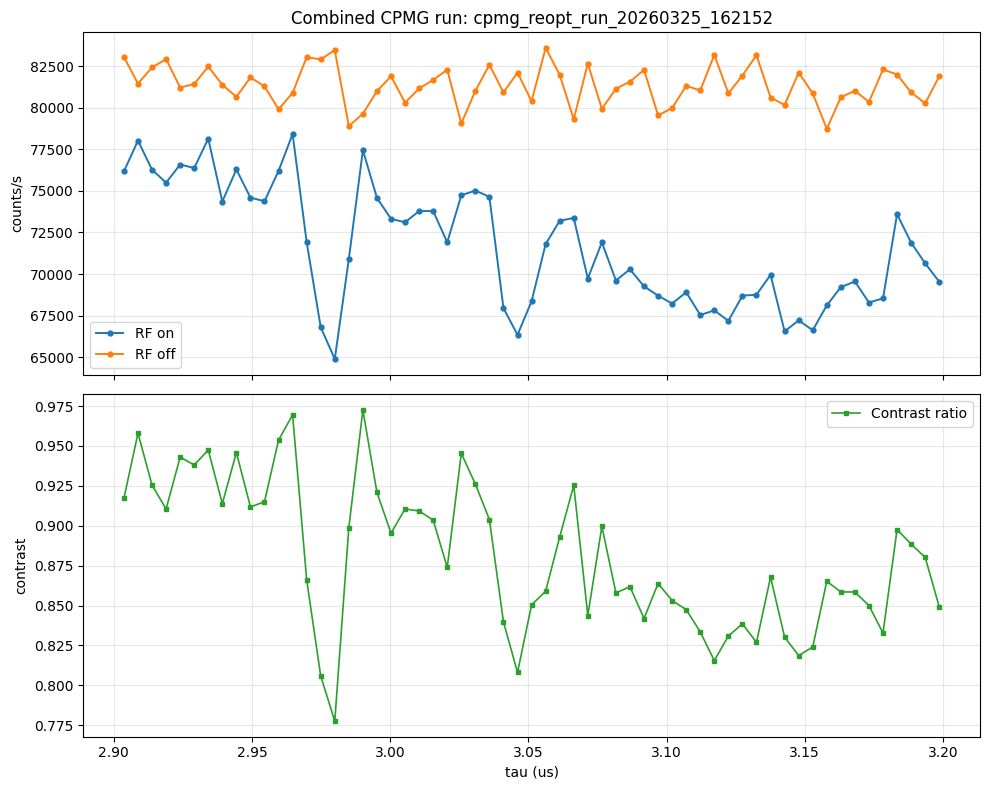

Plotted 161 signal points, 161 reference points, 161 contrast points vs tau (ns).


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Requires variables produced by the previous cell:
# tau_ns, signal, reference, contrast, run_path
required_vars = ["tau_ns", "signal", "reference", "contrast", "run_path"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(f"Run the previous combined-data extraction cell first. Missing: {missing}")

x = np.asarray(tau_ns/1e3, dtype=float).reshape(-1)
y_sig = np.asarray(signal, dtype=float).reshape(-1)
y_ref = np.asarray(reference, dtype=float).reshape(-1)
y_con = np.asarray(contrast, dtype=float).reshape(-1)

n_sig = min(len(x), len(y_sig))
n_ref = min(len(x), len(y_ref))
n_con = min(len(x), len(y_con))

# x is in microseconds (x = tau_ns / 1e3), so mask in us (not seconds)
mask = (x >= 2.9) & (x <= 3.2)
x = x[mask]
y_sig = y_sig[mask]
y_ref = y_ref[mask]
y_con = y_con[mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(x[:n_sig], y_sig[:n_sig], "o-", lw=1.4, ms=3.5, label="RF on")
ax1.plot(x[:n_ref], y_ref[:n_ref], "o-", lw=1.4, ms=3.5, label="RF off")
ax1.set_ylabel("counts/s")
run_dir_name = run_path.parent.name
ax1.set_title(f"Combined CPMG run: {run_dir_name}")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(x[:n_con], y_con[:n_con], "s-", lw=1.2, ms=3.2, color="tab:green", label="Contrast ratio")
ax2.set_xlabel("tau (us)")
ax2.set_ylabel("contrast")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Plotted {n_sig} signal points, {n_ref} reference points, {n_con} contrast points vs tau (ns).")

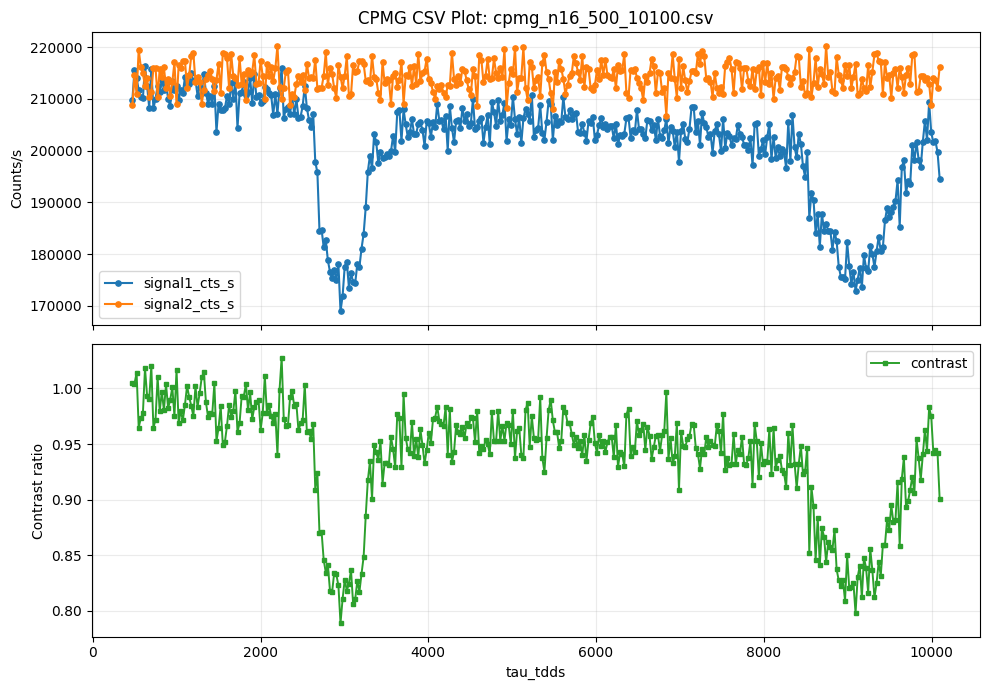

Plotted 385 rows from cpmg_n16_500_10100.csv


In [73]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = Path("cpmg_n16_500_10100.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find {csv_path.resolve()}")

df = pd.read_csv(csv_path)

required = ["tau_tdds", "signal1_cts_s", "signal2_cts_s", "contrast"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

tau_tdds = df["tau_tdds"].to_numpy(dtype=float)
signal = df["signal1_cts_s"].to_numpy(dtype=float)
reference = df["signal2_cts_s"].to_numpy(dtype=float)
contrast = df["contrast"].to_numpy(dtype=float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(tau_tdds, signal, "o-", lw=1.5, ms=3.8, label="signal1_cts_s")
ax1.plot(tau_tdds, reference, "o-", lw=1.5, ms=3.8, label="signal2_cts_s")
ax1.set_ylabel("Counts/s")
ax1.set_title(f"CPMG CSV Plot: {csv_path.name}")
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(tau_tdds, contrast, "s-", lw=1.4, ms=3.5, color="tab:green", label="contrast")
ax2.set_xlabel("tau_tdds")
ax2.set_ylabel("Contrast ratio")
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Plotted {len(df)} rows from {csv_path}")